## Plot branchwater output for the species-genes


In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

BP_THRESHOLD=0

BASE_OUTPUTS=BASE+'/outputs.cds/branchwater.cds3-genes/'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# remove shitty entries with shitty metatada
def remove_unnannotated(df: pl.DataFrame) -> pl.DataFrame:
    bad_values = [
        "metagenome",
        "gut metagenome",
        "feces metagenome",
        "manure metagenome",
        "bacterium",
        "unidentified",
        "null"
    ]
    return df.filter(~pl.col("organism").is_in(bad_values))


# group by organism and count number of bacteria per SRA 
def pivot_count(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by(["broad_cat", "count"])
        .len()  # count occurrences
        .pivot(
            values="len",
            index="broad_cat",
            on="count"
        )
        .fill_null(0)  # optional: fill missing with 0
    )

# set mapping for "categories of interest" I like human v pig v neither. 
category_map_simple = {
    'human associated': ['human', 'homo', 'sapiens'],
    'pig': ['pig', 'sus', 'scrofa']}

# Function to assign category based on keywords above
def get_broad_cat_simple(organism):
    for cat, keywords in category_map_simple.items():
        if any(keyword.lower() in str(organism).lower() for keyword in keywords):
            return cat
    return 'other'  

# colormap plotting
colors = {
    'pig': '#264653',
    'human associated': '#e76f51',
    'other': '#f4a261',
    'pig/other': '#2a9d8f',
    'pig-associated': '#e9c46a'
    }

In [4]:
dirpath = BASE_OUTPUTS+'/manysearch.*.parquet'

all_bw_df = pl.scan_parquet(dirpath).collect()
all_bw_df = all_bw_df.with_columns(
    species=pl.col("query_name"),
    acc=pl.col("match_name"),
    intersect_bp=pl.col("scaled")*pl.col("intersect_hashes"),
)
all_bw_df = all_bw_df.select(["species", "acc", "containment", "intersect_bp"])

n_species = all_bw_df['species'].n_unique()
n_acc = all_bw_df['acc'].n_unique()
print(f"loaded {len(all_bw_df)} branchwater results for {n_species} species containing {n_acc} metagenomes")

loaded 601949 branchwater results for 18 species containing 273234 metagenomes


In [5]:
names_3216_df = (pl.read_csv('../3216.manifest.csv')
                 .with_columns(acc=pl.col('name'))
                 ['acc'].unique().to_frame()
                )
assert len(names_3216_df) == 3216, len(names_3216_df)
names_3216 = set(names_3216_df['acc'].to_list())

all_bw_df = all_bw_df.filter(~pl.col('acc').is_in(names_3216))
print(f"remaining: {len(all_bw_df)} branchwater results for {n_species} species containing {n_acc} metagenomes")

remaining: 555303 branchwater results for 18 species containing 273234 metagenomes


In [6]:
# get metadata, only compare WGS
metadata_df = (
    pl.scan_parquet("/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet")
    .filter(pl.col("acc") != "NP")
    .filter(pl.col("assay_type") == "WGS")
    .select(["acc", "organism", "bioproject", "mbases", "host", "project_name"]) 
    .collect()
)
print(f"found metadata records for {len(metadata_df)} WGS metagenome data sets from the SRA")

found metadata records for 703916 WGS metagenome data sets from the SRA


In [7]:
rename_df = []
for organism in metadata_df['organism'].unique().to_list():
    simpleorg = 'other'
    if organism:
        for kw in ['human', 'homo']:
            if kw in organism.lower():
                simpleorg = 'human'
                break
        for kw in ['pig', 'sus', 'scrofa']:
            if kw in organism.lower():
                simpleorg = 'pig'
                break
    rename_df.append(dict(organism=organism, broad_cat=simpleorg))

rename_df = pl.DataFrame(rename_df)
rename_df['broad_cat'].value_counts().sort(by='count', descending=True)

broad_cat,count
str,u32
"""other""",10208
"""human""",165
"""pig""",36


In [8]:
metadata2_df = metadata_df.join(rename_df, on='organism', how='left', coalesce=True)
assert len(metadata2_df) == len(metadata_df)
metadata2_df

acc,organism,bioproject,mbases,host,project_name,broad_cat
str,str,str,i64,str,str,str
"""SRR28523869""","""human metagenome""","""PRJNA1095378""",258,"""[""Homo sapiens""]""",null,"""human"""
"""SRR19901137""","""Streptococcus suis""","""PRJNA854064""",40,"""[""Homo sapiens""]""",null,"""other"""
"""SRR24962475""","""Escherichia coli""","""PRJNA982891""",88,"""[""Homo sapiens""]""",null,"""other"""
"""SRR29161330""","""biofilm metagenome""","""PRJNA1116137""",3,"""[""metagenome""]""",null,"""other"""
"""SRR26668739""","""bovine gut metagenome""","""PRJNA1035769""",129,"""[""Bos taurus""]""",null,"""other"""
…,…,…,…,…,…,…
"""ERR4174288""","""human gut metagenome""","""PRJEB36461""",1017,null,"""[""Impact of Laparoscopic Roux-…","""human"""
"""ERR3160109""","""human gut metagenome""","""PRJEB23292""",133,null,"""[""Major microbiota dysbiosis i…","""human"""
"""ERR2709457""","""human gut metagenome""","""PRJEB27799""",964,null,"""[""Prediction of the intestinal…","""human"""


In [9]:
n_pig = len(metadata2_df.filter(pl.col('broad_cat') == 'pig'))
n_human = len(metadata2_df.filter(pl.col('broad_cat') == 'human'))

print(f"{n_pig} pig, {n_human} human metag")

9500 pig, 303365 human metag


In [10]:
n_pig_deep = len(metadata2_df.filter((pl.col('broad_cat') == 'pig') & (pl.col('mbases') >= 1000)))
n_human_deep = len(metadata2_df.filter((pl.col('broad_cat') == 'human') & (pl.col('mbases') >= 1000)))
print(f"deep: {n_pig_deep} pig, {n_human_deep} human metag")

deep: 5465 pig, 155835 human metag


In [11]:
all_bw_df = all_bw_df.join(metadata2_df, on="acc", how="left")
print(f"{all_bw_df['species'].n_unique()} species")

18 species


In [13]:
CORE_SPECIES=set([ x.strip() for x in open('../inputs.cds/names.list') ])
all_bw_df = all_bw_df.filter(pl.col("species").is_in(CORE_SPECIES))
print(f"{all_bw_df['species'].n_unique()} species left after filtering for core")
#assert all_bw_df['species'].n_unique() == len(CORE_SPECIES)

15 species left after filtering for core


In [14]:
# apply hash threshold
bw_df = all_bw_df.filter(pl.col("intersect_bp") >= BP_THRESHOLD)

# remove unnanotated metags (metagenome, gut metagenome, etc)
df = remove_unnannotated(bw_df)

# update with organism broad category
df = df.join(rename_df, on='organism', how='inner')


# count number of orgs (out of 16) in each mG
counts_df = (
    df
    .group_by(["acc", "broad_cat"])
    .len()
    .rename({"len": "count"})
)

print(counts_df)

# pivot for plotting
pl_dfp = pivot_count(counts_df)

# sort columns by number
assert pl_dfp.columns[0] == 'broad_cat'
sorted_cols = list(sorted(pl_dfp.columns[1:], key=lambda x: int(x)))
pl_dfp = pl_dfp.select(['broad_cat'] + sorted_cols)

print(pl_dfp)

shape: (176_927, 3)
┌─────────────┬───────────┬───────┐
│ acc         ┆ broad_cat ┆ count │
│ ---         ┆ ---       ┆ ---   │
│ str         ┆ str       ┆ u32   │
╞═════════════╪═══════════╪═══════╡
│ SRR21855356 ┆ other     ┆ 1     │
│ ERR11570111 ┆ human     ┆ 1     │
│ SRR30410471 ┆ other     ┆ 3     │
│ SRR10694911 ┆ other     ┆ 1     │
│ ERR3345704  ┆ other     ┆ 1     │
│ …           ┆ …         ┆ …     │
│ SRR11047658 ┆ human     ┆ 1     │
│ ERR11478205 ┆ human     ┆ 3     │
│ SRR14715258 ┆ human     ┆ 3     │
│ ERR12304212 ┆ human     ┆ 1     │
│ SRR12934131 ┆ human     ┆ 1     │
└─────────────┴───────────┴───────┘
shape: (3, 16)
┌───────────┬───────┬───────┬──────┬───┬─────┬─────┬─────┬─────┐
│ broad_cat ┆ 1     ┆ 2     ┆ 3    ┆ … ┆ 12  ┆ 13  ┆ 14  ┆ 15  │
│ ---       ┆ ---   ┆ ---   ┆ ---  ┆   ┆ --- ┆ --- ┆ --- ┆ --- │
│ str       ┆ u32   ┆ u32   ┆ u32  ┆   ┆ u32 ┆ u32 ┆ u32 ┆ u32 │
╞═══════════╪═══════╪═══════╪══════╪═══╪═════╪═════╪═════╪═════╡
│ other     ┆ 36428 ┆ 12005 

In [15]:
# transpose with sensible column names
df_cm = pl_dfp.transpose(include_header=True, header_name='index',
                 column_names=pl_dfp['broad_cat'].to_list())

# get rid of first row
df_cm = df_cm.tail(-1)

# change the values to all integer
df_cm = df_cm.with_columns(
    pl.col("index").str.to_integer(),
    pl.col("pig").str.to_integer(),
    pl.col("human").str.to_integer(),
    pl.col("other").str.to_integer()
)

df_cm = df_cm.with_columns(
    pl.col("pig").cum_sum(reverse=True).alias("cm_pig"),
    pl.col("human").cum_sum(reverse=True).alias("cm_human"),
    pl.col("other").cum_sum(reverse=True).alias("cm_other"),
)


df_cm = df_cm.with_columns(
    (pl.col("cm_pig") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_pig"),
    (pl.col("cm_human") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_human"),
    (pl.col("cm_other") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_other"),
)

print(df_cm)

shape: (15, 10)
┌───────┬───────┬───────┬─────┬───┬──────────┬──────────┬──────────┬──────────┐
│ index ┆ other ┆ human ┆ pig ┆ … ┆ cm_other ┆ f_pig    ┆ f_human  ┆ f_other  │
│ ---   ┆ ---   ┆ ---   ┆ --- ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64   ┆ i64   ┆ i64   ┆ i64 ┆   ┆ i64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════╪═══════╪═══════╪═════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ 1     ┆ 36428 ┆ 76220 ┆ 230 ┆ … ┆ 57152    ┆ 0.022631 ┆ 0.654343 ┆ 0.323026 │
│ 2     ┆ 12005 ┆ 26604 ┆ 197 ┆ … ┆ 20724    ┆ 0.058924 ┆ 0.617512 ┆ 0.323565 │
│ 3     ┆ 4565  ┆ 7981  ┆ 161 ┆ … ┆ 8719     ┆ 0.141703 ┆ 0.512895 ┆ 0.345403 │
│ 4     ┆ 1910  ┆ 2729  ┆ 145 ┆ … ┆ 4154     ┆ 0.272495 ┆ 0.396139 ┆ 0.331366 │
│ 5     ┆ 876   ┆ 1195  ┆ 151 ┆ … ┆ 2244     ┆ 0.421956 ┆ 0.288571 ┆ 0.289474 │
│ …     ┆ …     ┆ …     ┆ …   ┆ … ┆ …        ┆ …        ┆ …        ┆ …        │
│ 11    ┆ 82    ┆ 0     ┆ 408 ┆ … ┆ 465      ┆ 0.797391 ┆ 0.000435 ┆ 0.202174 │
│ 12    ┆ 91    ┆ 1     

Text(0, 0.5, 'Fraction of metagenomes')

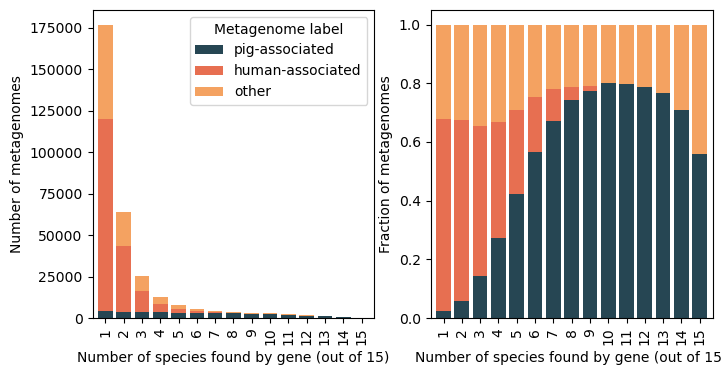

In [19]:
xlabels = df_cm['index'].to_list()
weights = {}
for col in ('cm_pig', 'cm_human', 'cm_other', 'f_pig', 'f_human', 'f_other'):
    weights[col] = df_cm[col].to_list()

labels = {}
labels['cm_human'] = 'human-associated'
labels['cm_other'] = 'other'
labels['cm_pig'] = 'pig-associated'
labels['f_human'] = 'human-associated'
labels['f_other'] = 'other'
labels['f_pig'] = 'pig-associated'

# colormap plotting
colors = {
    'cm_pig': '#264653',
    'cm_human': '#e76f51',
    'cm_other': '#f4a261',
    'f_pig': '#264653',
    'f_human': '#e76f51',
    'f_other': '#f4a261',
    }

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

bottom = np.zeros(len(xlabels))
for name in 'cm_pig', 'cm_human', 'cm_other':
    counts = weights[name]
    axes[0].bar(xlabels, counts, label=labels[name], bottom=bottom, color=colors[name])
    bottom += np.array(counts)

bottom = np.zeros(len(xlabels))
for name in 'f_pig', 'f_human', 'f_other':
    counts = weights[name] 
    axes[1].bar(xlabels, counts, label=labels[name], bottom=bottom, color=colors[name])
    bottom += np.array(counts)

for ax in axes:
    ax.set_xlim(0.3, 15.7)
    ax.set_xlabel('Number of species found by gene (out of 15)')
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(xlabels)

axes[0].legend(title='Metagenome label', loc='upper right')
axes[0].set_ylabel('Number of metagenomes')
axes[1].set_ylabel('Fraction of metagenomes')

## Figure XX: Core bacteria largely select against human-associated metagenomes.

FIXME
21-mer search of 700,000 public metagenomes with each of 16 bacterial species pangenomes  found almost 200,000 metagenomes containing at least one species at a containment threshold of 5%. Over 163,000 of these metagenomes were human-associated. Filtering metagenomes based on the number of contained species progressively eliminated the large majority of human metagenomes; when requiring 12 or more species, 80% of the pig metagenomes were retained while only 0.2% of the human metagenomes were retained.

(0.0, 60000.0)

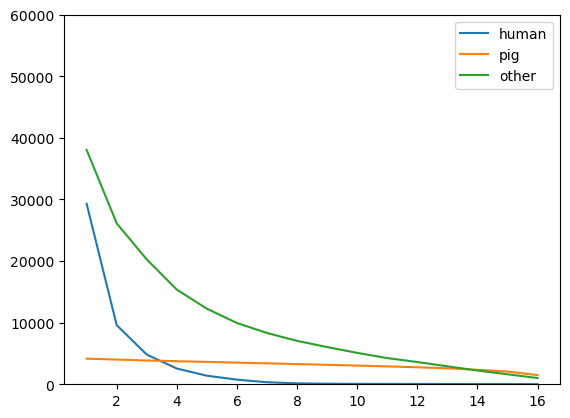

In [16]:
plt.plot(df_cm['index'], df_cm['cm_human'], label='human')
plt.plot(df_cm['index'], df_cm['cm_pig'], label='pig')
plt.plot(df_cm['index'], df_cm['cm_other'], label='other')

plt.legend(loc='upper right')
plt.ylim(0, 60000)

In [17]:
all_bw_df['broad_cat'].value_counts()

broad_cat,count
str,u32
"""pig""",70398
"""human""",1695638
"""other""",2945419
null,801474


In [18]:
d = metadata2_df['broad_cat'].value_counts().to_dict(as_series=False)

pig_idx = d['broad_cat'].index('pig')
n_orig_pig = d['count'][pig_idx]

human_idx = d['broad_cat'].index('human')
n_orig_human = d['count'][human_idx]

f_orig_pig = n_orig_pig / (n_orig_pig + n_orig_human)
f_orig_human = n_orig_human / (n_orig_pig + n_orig_human)

orig_pig_ratio = n_orig_pig / (n_orig_pig + n_orig_human)
orig_human_ratio = n_orig_human / (n_orig_pig + n_orig_human)

print(orig_pig_ratio, orig_human_ratio)

0.030364534224026338 0.9696354657759737


In [35]:

enrich_df = df_cm.with_columns(
    enrich_pig = (pl.col("cm_pig") / (pl.col("cm_pig") + pl.col("cm_human")) / orig_pig_ratio),
    enrich_human = (pl.col("cm_human") / (pl.col("cm_pig") + pl.col("cm_human")) / orig_human_ratio),
)
print(enrich_df)

shape: (16, 12)
┌───────┬───────┬──────┬───────┬───┬──────────┬──────────┬────────────┬──────────────┐
│ index ┆ human ┆ pig  ┆ other ┆ … ┆ f_human  ┆ f_other  ┆ enrich_pig ┆ enrich_human │
│ ---   ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---        ┆ ---          │
│ i64   ┆ i64   ┆ i64  ┆ i64   ┆   ┆ f64      ┆ f64      ┆ f64        ┆ f64          │
╞═══════╪═══════╪══════╪═══════╪═══╪══════════╪══════════╪════════════╪══════════════╡
│ 1     ┆ 19699 ┆ 148  ┆ 11917 ┆ … ┆ 0.409743 ┆ 0.5321   ┆ 4.093387   ┆ 0.903129     │
│ 2     ┆ 4774  ┆ 148  ┆ 5860  ┆ … ┆ 0.241518 ┆ 0.657556 ┆ 9.706156   ┆ 0.727363     │
│ 3     ┆ 2269  ┆ 114  ┆ 4900  ┆ … ┆ 0.166563 ┆ 0.700035 ┆ 14.646229  ┆ 0.572663     │
│ 4     ┆ 1162  ┆ 112  ┆ 3101  ┆ … ┆ 0.117829 ┆ 0.709189 ┆ 19.589506  ┆ 0.417862     │
│ 5     ┆ 643   ┆ 123  ┆ 2318  ┆ … ┆ 0.080442 ┆ 0.709288 ┆ 23.820362  ┆ 0.285371     │
│ …     ┆ …     ┆ …    ┆ …     ┆ … ┆ …        ┆ …        ┆ …          ┆ …            │
│ 12    ┆ 12    ┆ 163  ┆ 69

(0.0, 40.0)

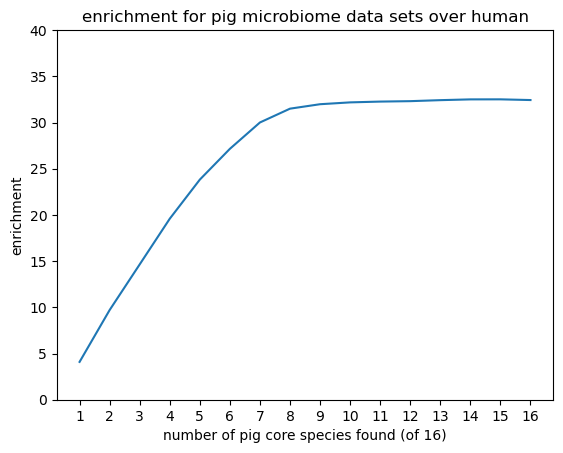

In [39]:
# plt.plot(enrich_df['index'], enrich_df['enrich_human'], label='human enrichment')
plt.plot(enrich_df['index'], enrich_df['enrich_pig'], label='pig enrichment')
plt.title('enrichment for pig microbiome data sets over human')
plt.xlabel('number of pig core species found (of 16)')
plt.ylabel('enrichment')
plt.xticks(range(1, 17))

#plt.legend(loc='upper right')
plt.ylim(0, 40)